In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pca import pca
import os
import matplotlib.pyplot as plt
os.chdir('/home/pgcp-ai/MachineLearning/Datasets/')

In [2]:
milk = pd.read_csv("milk.csv", index_col = 0)
milk.shape

(25, 5)

In [3]:
milk

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85


In [4]:
scaler = StandardScaler().set_output(transform = 'pandas')
milk_scaled = scaler.fit_transform(milk)

In [10]:
prcomp = PCA().set_output(transform = 'pandas')
pc_data = prcomp.fit_transform(milk_scaled)
pc_data.var()

pca0    4.040412
pca1    0.924372
pca2    0.134291
pca3    0.102689
pca4    0.006570
dtype: float64

In [11]:
prcomp.components_

array([[-0.47294379,  0.46657047,  0.44868269, -0.48289116,  0.35232959],
       [ 0.35285509,  0.32094099, -0.47603724,  0.05951482,  0.73643513],
       [-0.36921298, -0.15196177,  0.30699163,  0.77642589,  0.378825  ],
       [-0.10893632,  0.78672876, -0.17660367,  0.38468756, -0.43590982],
       [-0.70967042, -0.1930657 , -0.66831106, -0.11159049,  0.00118661]])

In [27]:
pc_data.values

array([[-2.43517478e+00, -2.31477535e-01,  3.30150277e-01,
         3.07663789e-01, -4.81844020e-02],
       [-2.25873578e+00, -6.93147702e-01,  2.90345634e-02,
        -8.10566235e-02,  5.31875986e-04],
       [-2.33586051e+00, -6.63328405e-01,  1.01257424e-01,
         2.47997451e-01, -1.01090469e-02],
       [-2.31867737e+00, -2.73814696e-01,  1.09881468e-01,
        -9.28730047e-02,  6.76869081e-03],
       [-2.06029437e+00, -1.01919913e+00, -7.62435692e-01,
        -5.10091168e-01, -2.93815549e-02],
       [-1.30153554e+00,  1.37302686e-01, -1.98742464e-01,
        -2.82160412e-01,  1.46681977e-02],
       [-1.28274231e+00,  6.22666596e-01,  2.53785220e-01,
         6.51479675e-02,  4.44863325e-02],
       [-5.05068322e-01,  8.82353252e-02,  8.38298039e-03,
         1.33774458e-01, -8.38059103e-02],
       [ 2.55501845e-01,  2.87373242e-01, -8.81856866e-01,
        -1.30998847e-02,  1.64841025e-02],
       [ 5.10084403e-02,  4.70135842e-01, -3.55676176e-01,
         1.05096967e+00

In [13]:
values, vectors = np.linalg.eig(milk_scaled.cov())
print("Eigen Values: ", values)
print("Eigen vectors: ", vectors)

Eigen Values:  [4.0404117  0.92437238 0.00656977 0.13429088 0.1026886 ]
Eigen vectors:  [[-0.47294379  0.35285509 -0.70967042  0.36921298  0.10893632]
 [ 0.46657047  0.32094099 -0.1930657   0.15196177 -0.78672876]
 [ 0.44868269 -0.47603724 -0.66831106 -0.30699163  0.17660367]
 [-0.48289116  0.05951482 -0.11159049 -0.77642589 -0.38468756]
 [ 0.35232959  0.73643513  0.00118661 -0.378825    0.43590982]]


In [14]:
prcomp.explained_variance_

array([4.0404117 , 0.92437238, 0.13429088, 0.1026886 , 0.00656977])

In [15]:
prcomp.explained_variance_ / np.sum(prcomp.explained_variance_)

array([0.77575905, 0.1774795 , 0.02578385, 0.01971621, 0.0012614 ])

### How principal components explain capturing of data

In [19]:
np.cumsum(prcomp.explained_variance_ratio_ * 100)

array([ 77.57590469,  95.32385438,  97.90223934,  99.87386037,
       100.        ])

[24-04-2026 16:06:24] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 5 columns of the input data.
[24-04-2026 16:06:24] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:06:24] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:06:24] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:06:24] [pca.pca] [INFO] The top 2 principal component(s) explains >= 95.00% of the explained variance.
[24-04-2026 16:06:24] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[24-04-2026 16:06:24] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:06:24] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:06:24] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[24-04-2026 16:06:24] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-04-2026 16:06:24] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[24

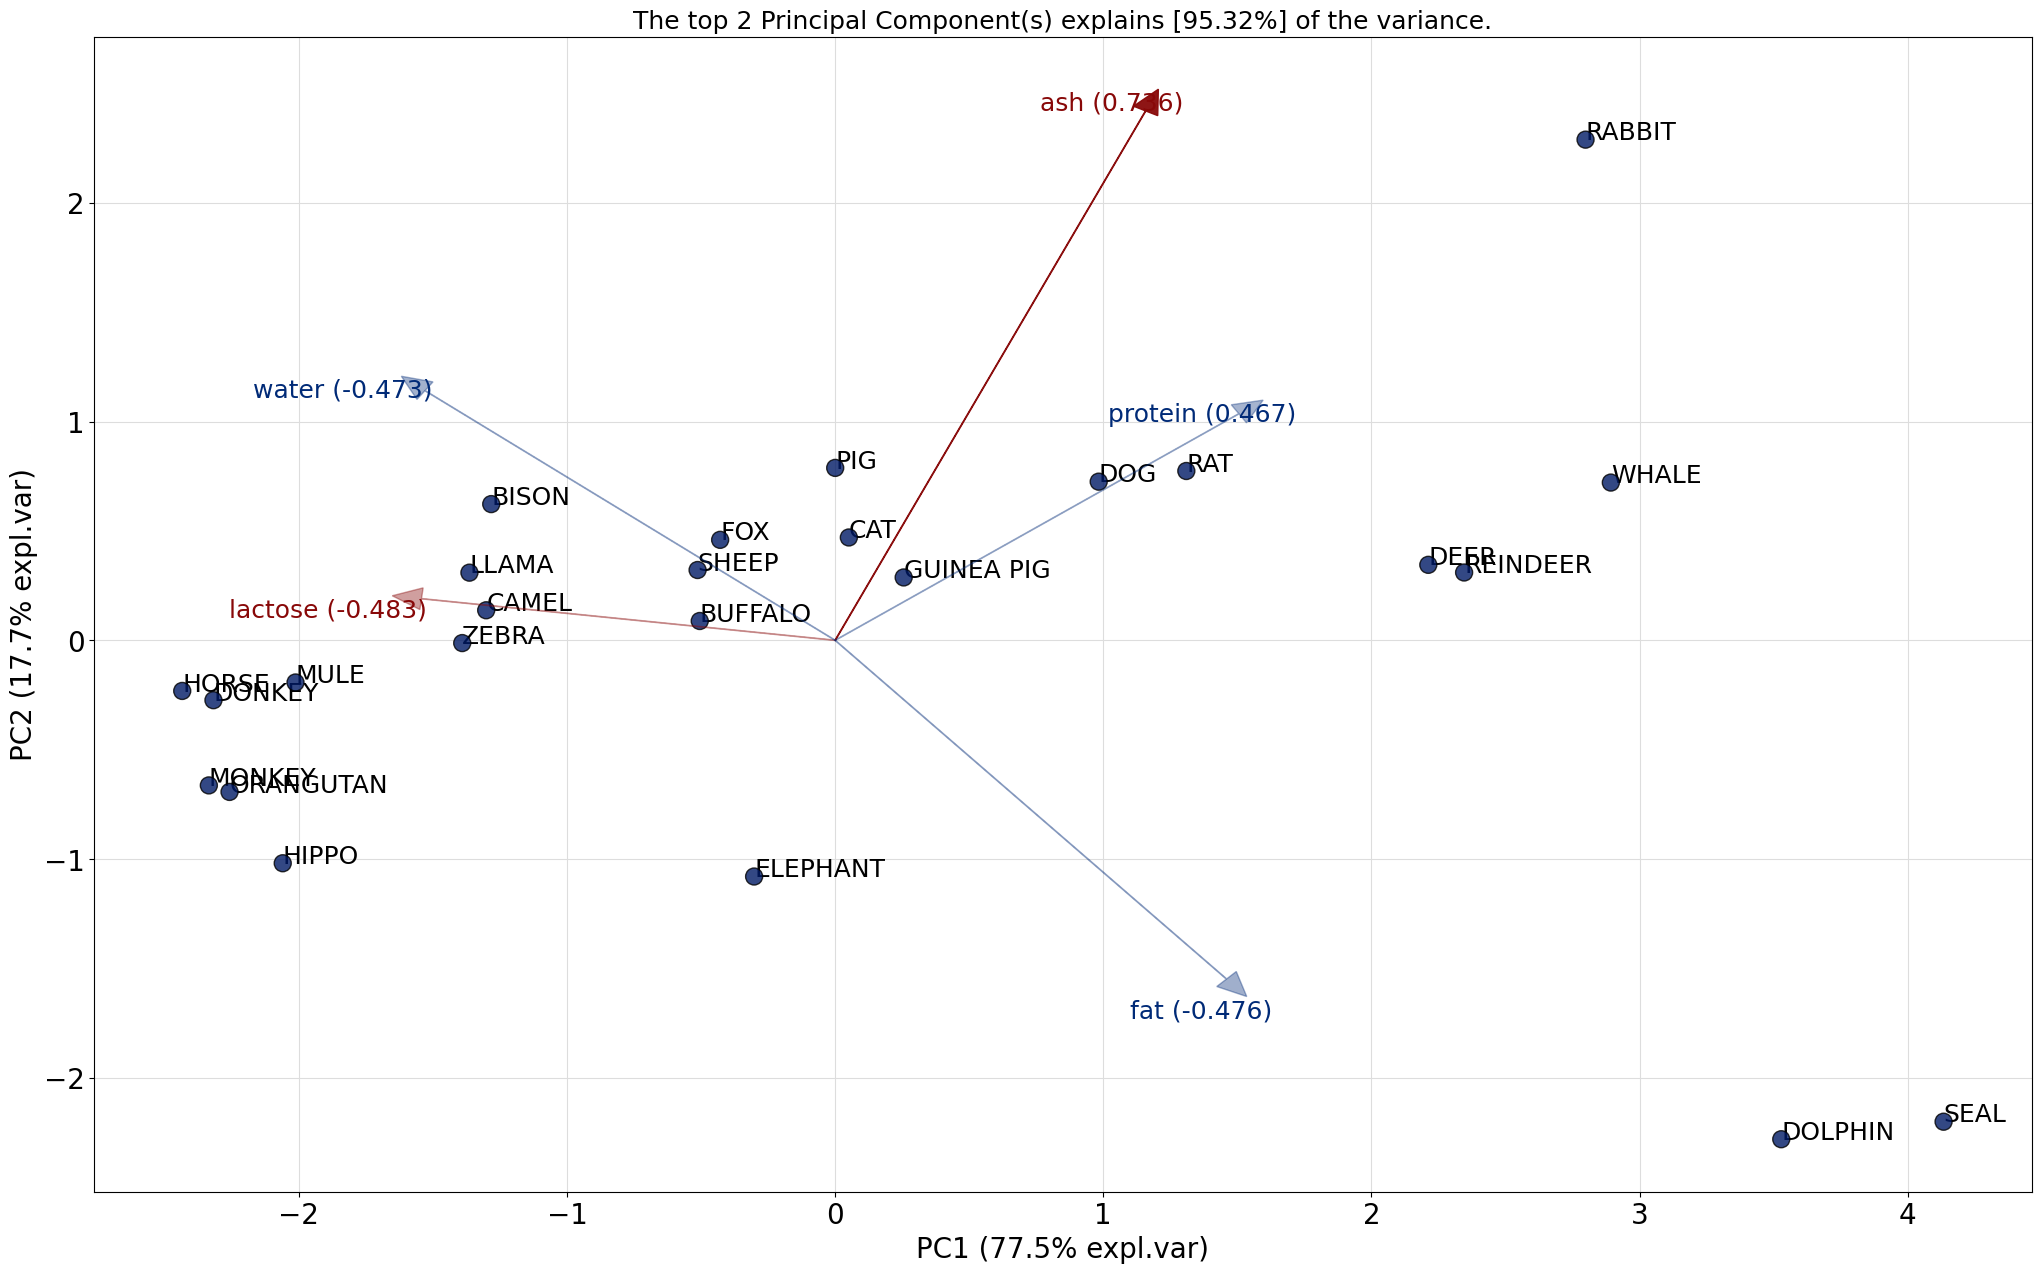

In [28]:
model = pca()
results = model.fit_transform(milk_scaled, col_labels = milk.columns, row_labels = list(milk.index))

model.biplot(label = True, legend = True)
for i in np.arange(0, milk.shape[0]):
    plt.text(pc_data.values[i, 0],
            pc_data.values[i, 1],
            list(milk.index)[i])
plt.show()

In [70]:
nutrient = pd.read_csv('nutrient.csv',index_col='Food_Item')
nutrient

,energy,protein,fat,calcium,iron
Food_Item,,,,,
BEEF BRAISED,340,20,28,9,2.6
HAMBURGER,245,21,17,9,2.7
BEEF ROAST,420,15,39,7,2.0
BEEF STEAK,375,19,32,9,2.6
BEEF CANNED,180,22,10,17,3.7
CHICKEN BROILED,115,20,3,8,1.4
CHICKEN CANNED,170,25,7,12,1.5
BEEF HEART,160,26,5,14,5.9
LAMB LEG ROAST,265,20,20,9,2.6


In [71]:
ss = StandardScaler().set_output(transform = 'pandas')
pca = PCA().set_output(transform='pandas')
nutrient_scaled  = ss.fit_transform(nutrient)
pca_data = pca.fit_transform(nutrient_scaled)

In [72]:
pca_data

,pca0,pca1,pca2,pca3,pca4
Food_Item,,,,,
BEEF BRAISED,1.894907,0.318029,0.003579,0.327156,0.005915
HAMBURGER,0.659812,-0.079563,0.512841,0.166202,-0.002632
BEEF ROAST,2.936755,1.122724,-1.097788,-0.226335,0.003483
BEEF STEAK,2.321069,0.585663,-0.239173,0.318095,0.028400
BEEF CANNED,-0.256477,0.054382,1.168707,0.474857,-0.042641
CHICKEN BROILED,-0.932996,-0.905719,0.393767,-0.815849,-0.031897
CHICKEN CANNED,-0.185016,-1.564189,0.789681,0.039419,-0.015362
BEEF HEART,-0.699024,0.346282,2.595080,1.568667,0.045738
LAMB LEG ROAST,0.937389,0.108904,0.274877,0.082978,-0.024877


In [73]:
pca.components_

array([[ 0.65428251,  0.15073191,  0.63991067, -0.35497845, -0.11704241],
       [ 0.08533006, -0.68933242,  0.19978707, -0.00314436,  0.69109684],
       [-0.15068976,  0.46268437, -0.21748273, -0.65138247,  0.54001659],
       [ 0.19703438,  0.52649179,  0.13170953,  0.67057536,  0.46579517],
       [ 0.7092977 , -0.10406865, -0.69710352,  0.00316007,  0.01015761]])

In [74]:
pca.explained_variance_ratio_

array([4.39264687e-01, 2.29177954e-01, 1.69542689e-01, 1.61694340e-01,
       3.20329884e-04])

In [75]:
pca.explained_variance_

array([2.28079741e+00, 1.18996245e+00, 8.80317810e-01, 8.39566765e-01,
       1.66325132e-03])

In [76]:
pca.explained_variance_ratio_*100

array([4.39264687e+01, 2.29177954e+01, 1.69542689e+01, 1.61694340e+01,
       3.20329884e-02])

In [77]:
np.cumsum(pca.explained_variance_ratio_)*100

array([ 43.92646868,  66.84426409,  83.79853301,  99.96796701,
       100.        ])

In [78]:
eigenvalues, eigenvectors = np.linalg.eig(pca_data.cov())
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:", eigenvectors)

Eigenvalues: [2.28079741e+00 1.18996245e+00 8.80317810e-01 8.39566765e-01
 1.66325132e-03]
Eigenvectors: [[ 1.00000000e+00 -3.83793502e-17 -1.03154024e-16  5.93221907e-17
  -9.69583802e-20]
 [ 0.00000000e+00 -1.00000000e+00  9.91537308e-17 -4.72865947e-16
  -2.64523816e-17]
 [ 0.00000000e+00  6.30639981e-16 -1.00000000e+00  1.15015238e-15
   3.69414175e-17]
 [ 0.00000000e+00  6.18134518e-16  1.81460259e-15 -1.00000000e+00
   9.03780964e-17]
 [ 0.00000000e+00 -6.42011446e-18 -8.20840677e-18 -4.52760085e-18
   1.00000000e+00]]


[24-04-2026 16:22:05] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 5 columns of the input data.
[24-04-2026 16:22:05] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:22:05] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:22:05] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:22:05] [pca.pca] [INFO] The top 4 principal component(s) explains >= 95.00% of the explained variance.
[24-04-2026 16:22:05] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[24-04-2026 16:22:05] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:22:05] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:22:05] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[4]
[24-04-2026 16:22:05] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-04-2026 16:22:05] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[24

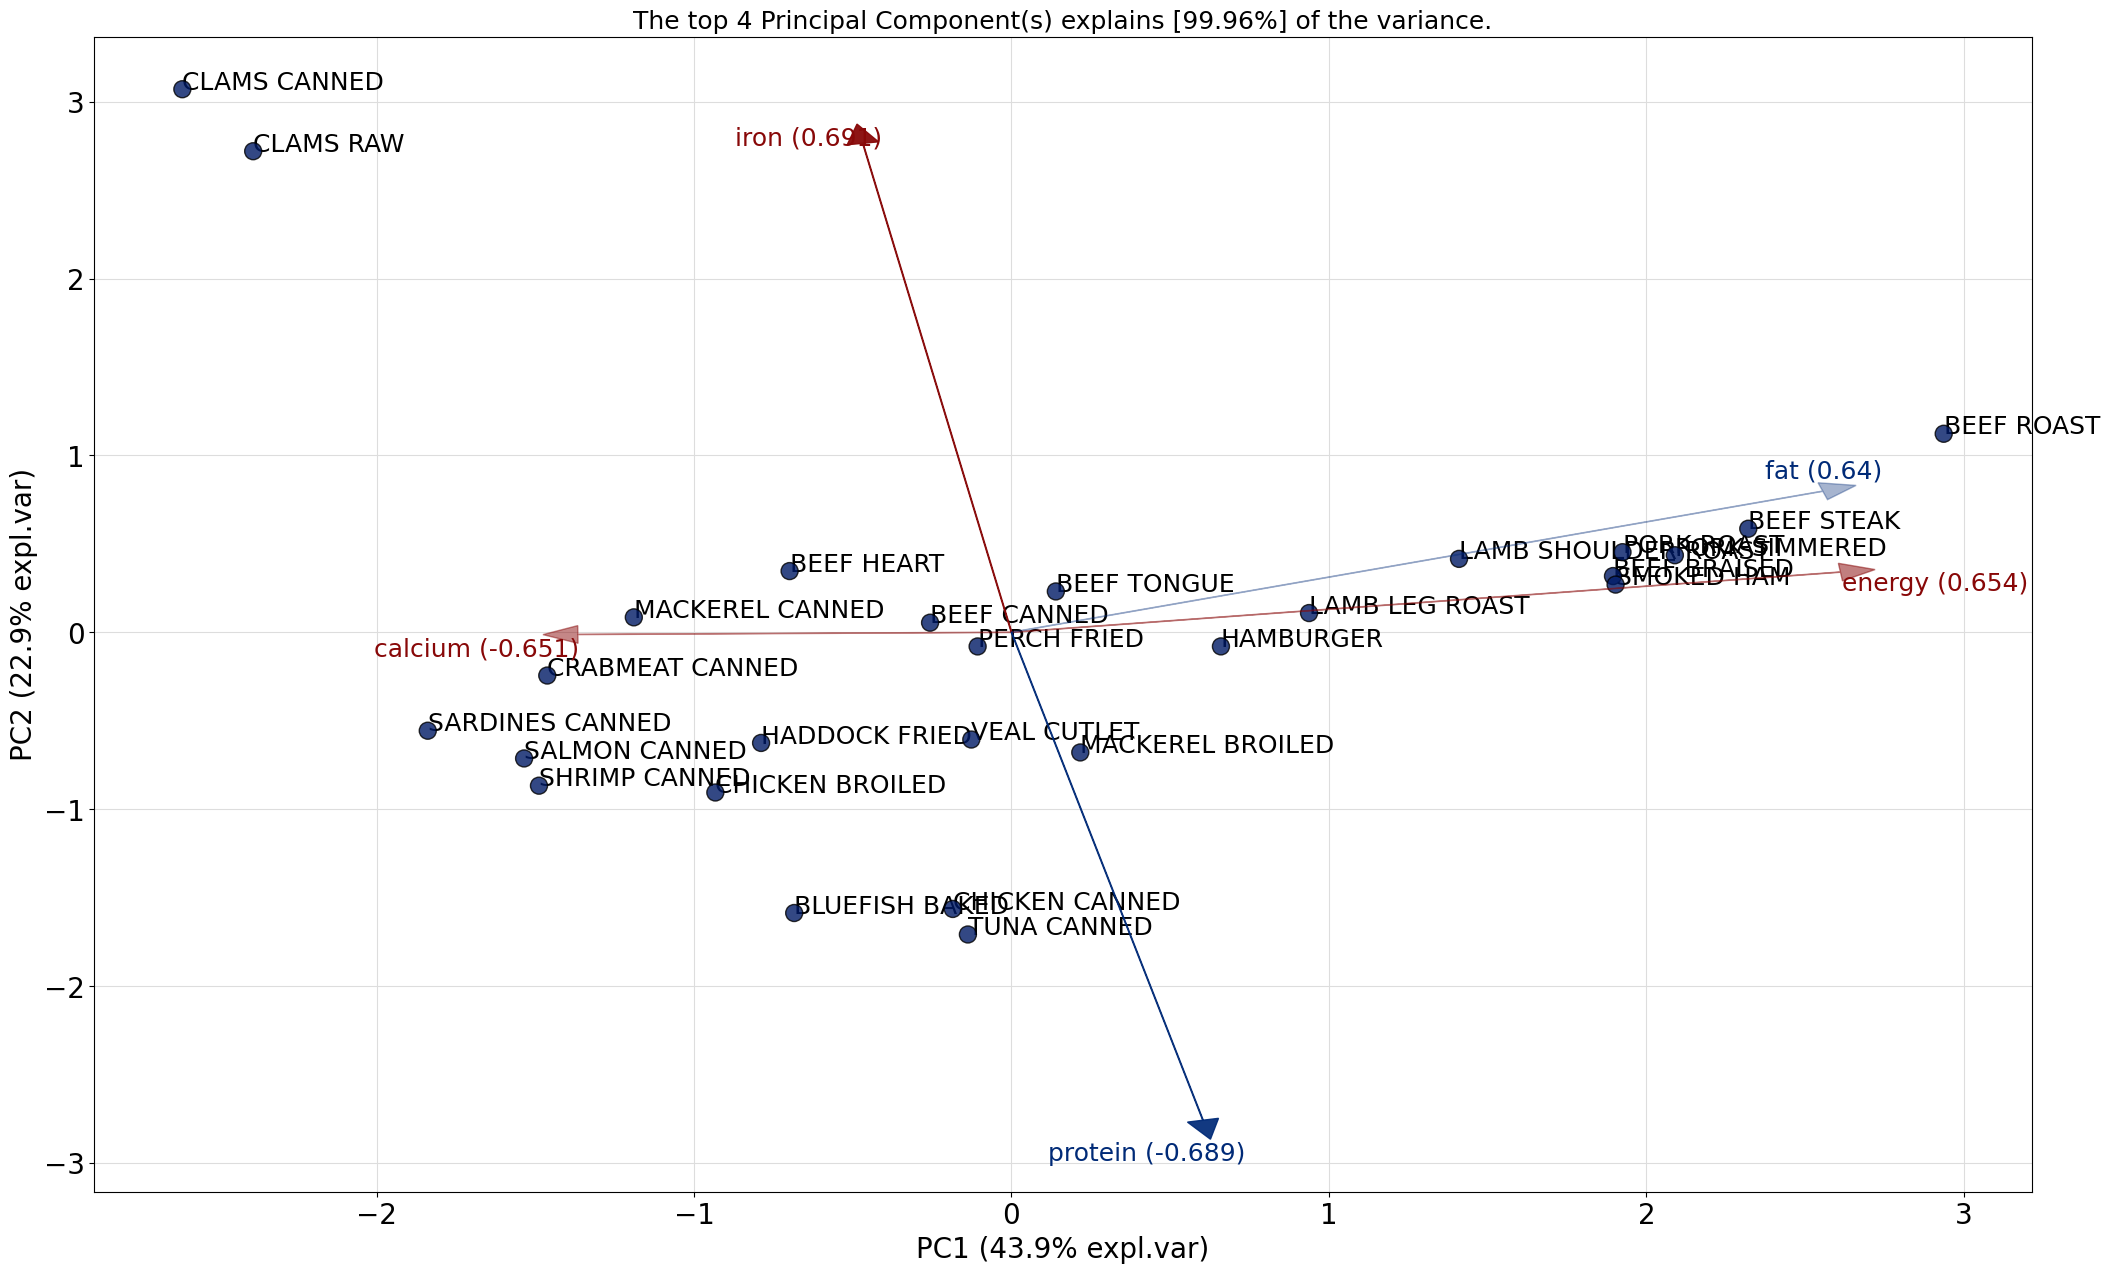

In [80]:
# model = pca()
results = model.fit_transform(nutrient_scaled, col_labels = nutrient.columns, row_labels = list(nutrient.index))

model.biplot(label = True, legend = True)
for i in np.arange(0, nutrient.shape[0]):
    plt.text(pca_data.values[i, 0],
            pca_data.values[i, 1],
            list(nutrient.index)[i])
plt.show()

In [83]:
arrests = pd.read_csv("USArrests.csv",index_col=0)


(50, 4)

In [84]:
arrests_scaled = ss.fit_transform(arrests)

In [85]:
pca_data = pca.fit_transform(arrests_scaled)

In [86]:
pca.explained_variance_

array([2.53085875, 1.00996444, 0.36383998, 0.17696948])

In [87]:
pca.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

In [88]:
np.cumsum(pca.explained_variance_ratio_*100)

array([ 62.00603948,  86.75016829,  95.66424781, 100.        ])

In [90]:
eigen_values, eigenvectors = np.linalg.eig(pca_data.cov())
eigenvectors

array([[ 1.00000000e+00, -7.13530781e-17,  7.44988943e-17,
         6.61451215e-17],
       [ 0.00000000e+00,  1.00000000e+00,  9.90436600e-17,
         4.26373357e-17],
       [ 0.00000000e+00, -1.81170571e-16,  1.51066509e-16,
         1.00000000e+00],
       [ 0.00000000e+00,  4.10167224e-16, -1.00000000e+00,
         2.00290257e-17]])

In [95]:
eigen_values

array([2.53085875, 1.00996444, 0.17696948, 0.36383998])

In [92]:
pca.components_

array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [ 0.41818087,  0.1879856 , -0.87280619, -0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [ 0.6492278 , -0.74340748,  0.13387773,  0.08902432]])

[24-04-2026 16:29:39] [pca.pca] [INFO] Cleaning previous fitted model results...
[24-04-2026 16:29:39] [pca.pca] [INFO] Row labels are auto-completed.
[24-04-2026 16:29:39] [pca.pca] [INFO] The PCA reduction is performed on 4 variables (columns) of the input dataframe.
[24-04-2026 16:29:39] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:29:39] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:29:39] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:29:39] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[4]
[24-04-2026 16:29:39] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-04-2026 16:29:39] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[24-04-2026 16:29:39] [pca.pca] [WARNING] Parameter <label> is deprecated and will not be supported in future version.
[24-04-2026 16:29:39] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[24-04-2026 16:29:39] [scatterd.scatterd] [

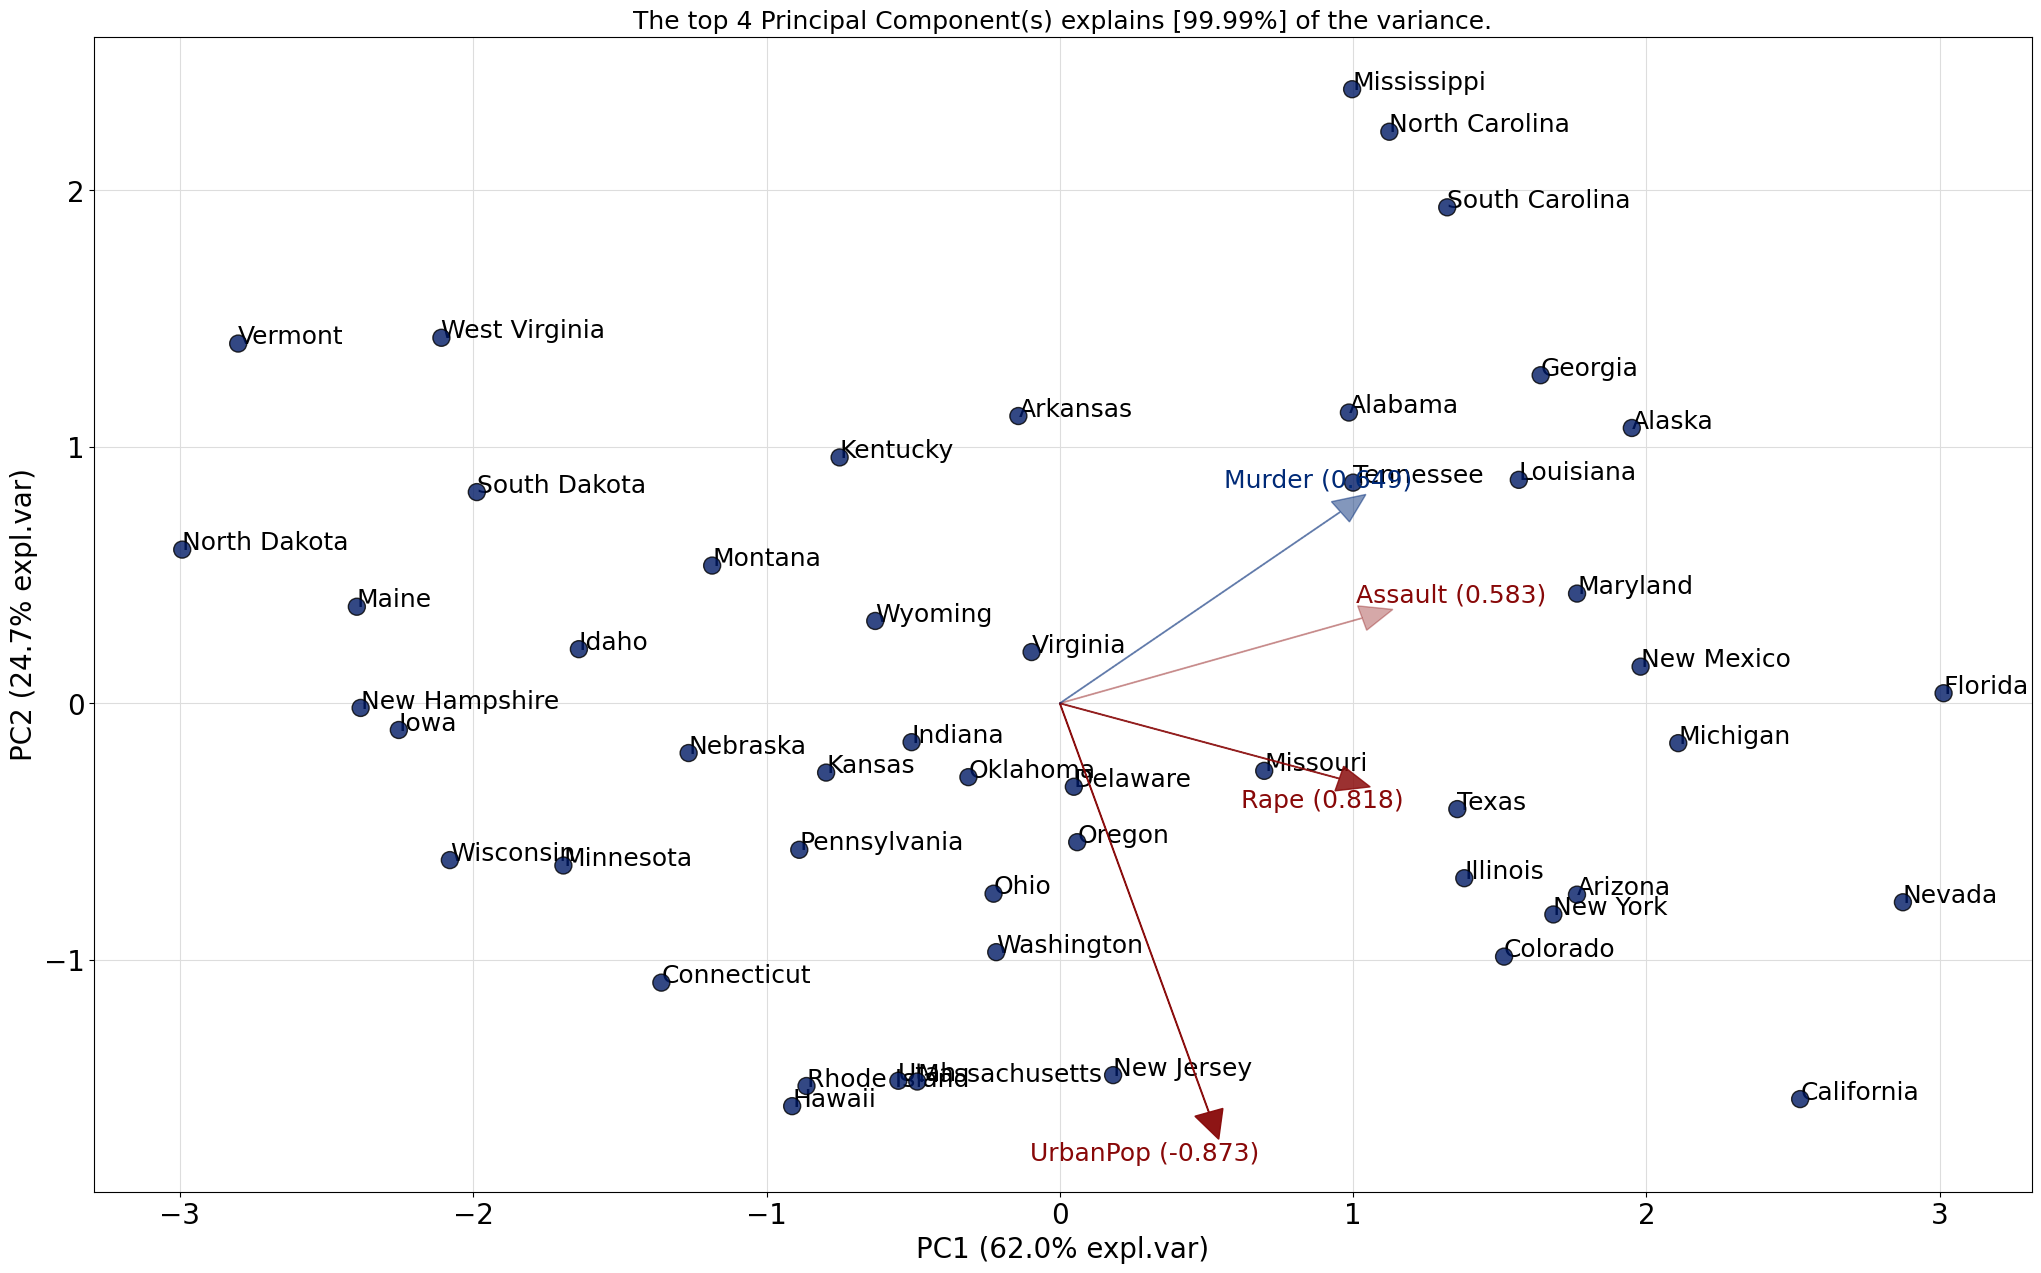

In [94]:
results = model.fit_transform(arrests_scaled, col_labels = arrests.columns, row_labels = list(nutrient.index))

model.biplot(label = True, legend = True)
for i in np.arange(0, arrests.shape[0]):
    plt.text(pca_data.values[i, 0],
            pca_data.values[i, 1],
            list(arrests.index)[i])
plt.show()